# Problem 1 Judge-Facing Split Notebook

이 notebook은 Problem 1의 최종 풀이를 제시한다. \(S_0\) target ensemble 생성, fidelity/MMD/Wasserstein-type distance 정의, random-unitary diffusion trajectory, Haar reference 해석을 포함한다. 실행 재현은 `../README.md`와 `../code/submission/run_all.py`를 따른다.

## Final Problem 1 Summary

- **Problem 1(a):** construct the initial two-qubit target ensemble `S0` clustered near `|00>`. The canonical final settings are `N=80`, `sigma=0.10`, and fixed seed `7` in the source-code reproduction path.
- **Problem 1(b):** use fidelity \(F(\psi,\phi)=|\langle\psi|\phi\rangle|^2\), fidelity-kernel MMD \(D_{\mathrm{MMD}}\), and Wasserstein-type distance \(W_{1-F}\) with pairwise cost \(1-F\).
- **Problem 1(c):** apply random-unitary layers to obtain \(S_k^{\mathrm{RU}}\) and compare distances to \(S_0\). The Haar baseline is a reference level, not a training target.

The final Problem 1(c) figure is `figures/fig2_random_unitary_haar_baseline.png`. It emphasizes the Haar mean, one-standard-deviation band, and plateau zoom so the strong-scrambling / Haar-like interpretation is visible.


## Final Problem 1(c) Haar Reference Figure

The final Problem 1(c) answer uses the cleaned Haar-reference figure below. The black dashed line is the Haar reference mean, the gold band is the Haar mean \(\pm\) one standard deviation, and the lower panels zoom into the \(k \geq 1\) plateau so the baseline remains visible when the random-unitary trajectory overlaps it.

![Problem 1(c) readable Haar baseline](figures/fig2_random_unitary_haar_baseline.png)


## 실행 환경


In [1]:
!pip install -q qiskit qiskit-aer scipy numpy matplotlib

import numpy as np
import scipy.linalg as la
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.circuit.library import RXGate, RYGate, RZGate, CXGate

print("✔ 모든 양자 컴퓨팅 및 시각화 라이브러리가 성공적으로 로드되었습니다.")



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ 모든 양자 컴퓨팅 및 시각화 라이브러리가 성공적으로 로드되었습니다.


## Problem 1. Random-Unitary Forward Diffusion

문제 1에서는 `|00>` 주변의 target ensemble을 구성하고, fidelity 기반 MMD-type distance와 Wasserstein-type distance를 정의한다. 이후 random unitary scrambling을 반복하여 forward diffusion trajectory를 만든다.


In [2]:
def generate_initial_ensemble(num_samples: int = 80, sigma: float = 0.10) -> list[Statevector]:
    """
    |00> 상태를 중심으로 미세한 각도 변위를 가진 양자 상태 앙상블을 생성합니다.

    Args:
        num_samples (int): 앙상블 크기 N (문제 조건: 50~100)
        sigma (float): 회전 각도를 추출할 정규분포의 표준편차
    Returns:
        list[Statevector]: 생성된 Statevector 객체들의 리스트
    """
    np.random.seed(2026)

    ensemble = []

    for _ in range(num_samples):
        qc = QuantumCircuit(2)

        for q in range(2):
            delta_y = np.random.normal(0, sigma)
            delta_z = np.random.normal(0, sigma)

            qc.ry(delta_y, q)
            qc.rz(delta_z, q)

        ensemble.append(Statevector(qc))

    return ensemble

N_SAMPLES = 80
SIGMA_VAL = 0.10

S_0 = generate_initial_ensemble(num_samples=N_SAMPLES, sigma=SIGMA_VAL)

print(f"✔ 앙상블 S_0 생성 완료 (총 {len(S_0)}개의 2-큐빗 상태벡터)")
print(f"  - 예시 상태벡터 0번의 기준 충실도 <00|psi_0> : {np.abs(S_0[0].data[0])**2:.4f}")


✔ 앙상블 S_0 생성 완료 (총 80개의 2-큐빗 상태벡터)
  - 예시 상태벡터 0번의 기준 충실도 <00|psi_0> : 0.9993


In [3]:
def compute_pairwise_fidelity_matrix(ens1: list[Statevector], ens2: list[Statevector]) -> np.ndarray:
    """Compute pairwise fidelity F(psi, phi) = |<psi|phi>|^2 for two ensembles."""
    N1, N2 = len(ens1), len(ens2)
    F_matrix = np.zeros((N1, N2))
    for i in range(N1):
        for j in range(N2):
            F_matrix[i, j] = state_fidelity(ens1[i], ens2[j])
    return F_matrix

def compute_mmd_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    Fidelity 커널 K(psi, phi) = |<psi|phi>|^2 을 이용한 MMD^2 거리를 계산합니다.
    MMD^2 = E[K(A,A)] - 2E[K(A,B)] + E[K(B,B)]
    """
    K_AA = compute_pairwise_fidelity_matrix(ens_A, ens_A)
    K_BB = compute_pairwise_fidelity_matrix(ens_B, ens_B)
    K_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)

    mmd_sq = np.mean(K_AA) - 2 * np.mean(K_AB) + np.mean(K_BB)
    return float(np.maximum(mmd_sq, 0.0))

def compute_wasserstein_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    비충실도 Cost(psi, phi) = 1 - Fidelity 를 비용 함수로 사용하는 최적 운송(Optimal Transport) 거리를 계산합니다.
    (두 앙상블의 크기가 같으므로 헝가리안 알고리즘을 통해 일대일 매칭 최소 비용 연산)
    """
    F_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)
    cost_matrix = 1.0 - F_AB

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    total_cost = cost_matrix[row_ind, col_ind].sum()

    return float(total_cost / len(ens_A))

print("✔ MMD 거리 및 Wasserstein 거리 연산 엔진이 정의되었습니다.")


✔ MMD 거리 및 Wasserstein 거리 연산 엔진이 정의되었습니다.


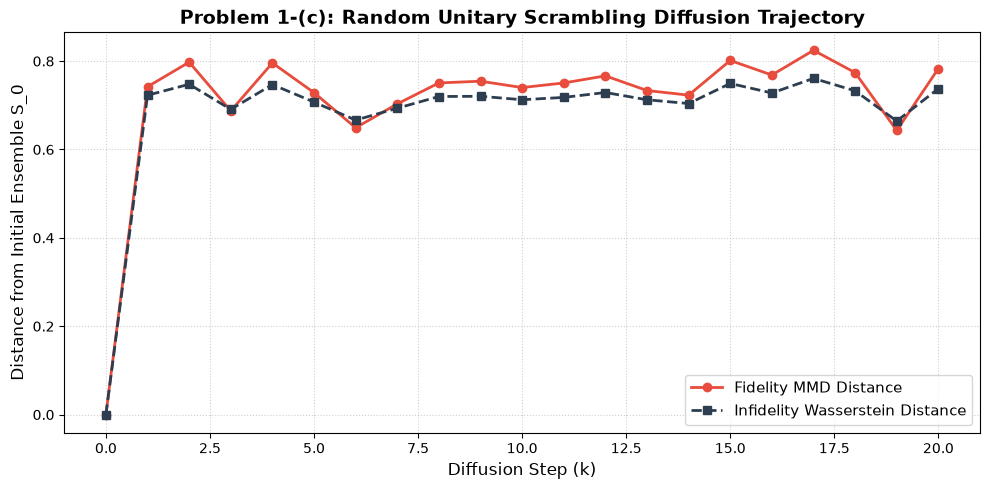

✔ 정성적 설명 포인트: 초기에 급격히 거리가 벌어지며, 이는 클러스터 구조가 힐베르트 공간 전체로 빠르게 해체(Scrambling)됨을 의미합니다.


In [4]:
def apply_random_unitary_layer(state: Statevector) -> Statevector:
    """1회 스크램블링 스텝: 임의의 단일 큐빗 회전 + 얽힘(CX) 게이트 인가"""
    qc = QuantumCircuit(2)
    qc.initialize(state.data, [0, 1])

    for q in range(2):
        qc.u(np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), q)

    qc.cx(0, 1)
    return Statevector(qc)

STEPS_RU = 20
S_k_history = [S_0]

np.random.seed(42)

current_ensemble = S_0
for step in range(1, STEPS_RU + 1):
    next_ensemble = [apply_random_unitary_layer(psi) for psi in current_ensemble]
    S_k_history.append(next_ensemble)
    current_ensemble = next_ensemble

mmd_list_ru = [compute_mmd_distance(S_0, S_k) for S_k in S_k_history]
wass_list_ru = [compute_wasserstein_distance(S_0, S_k) for S_k in S_k_history]

plt.figure(figsize=(10, 5))
plt.plot(range(STEPS_RU + 1), mmd_list_ru, 'o-', color='#e74c3c', label='Fidelity MMD Distance', lw=2)
plt.plot(range(STEPS_RU + 1), wass_list_ru, 's--', color='#2c3e50', label='Infidelity Wasserstein Distance', lw=2)
plt.title("Problem 1-(c): Random Unitary Scrambling Diffusion Trajectory", fontsize=14, fontweight='bold')
plt.xlabel("Diffusion Step (k)", fontsize=12)
plt.ylabel("Distance from Initial Ensemble S_0", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("✔ 정성적 설명 포인트: 초기에 급격히 거리가 벌어지며, 이는 클러스터 구조가 힐베르트 공간 전체로 빠르게 해체(Scrambling)됨을 의미합니다.")


### 해설

random-unitary diffusion trajectory는 고정 seed를 사용해 재현 가능한 경로로 생성한다.


### Problem 1 결과 해석

Target ensemble `S_0`는 `|00>` 근처의 작은 양자 상태 분포이다. Random-unitary step이 증가하면 각 sample이 Hilbert space 안에서 더 넓게 퍼지며, `S_0`와의 MMD/Wasserstein-type distance가 증가하거나 요동한다. 이 trajectory는 문제 3의 denoising 입력으로 사용된다.
